# Ejercicio Practico 3


## Grupo 7

### Importante: Ejecutar los pasos indicados en el archivo Readme.md

## Correr ejercicio 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creamos un dataset simulando un registro de conexiones de red
data = {
    'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='H'),
    'ip_origen': ['192.168.1.' + str(i) for i in range(1, 11)],
    'ip_destino': ['10.0.0.' + str(i % 3 + 1) for i in range(10)],
    'puerto': [80, 443, 22, 3389, 8080, 80, 443, 22, 8080, 3389],
    'protocolo': ['HTTP', 'HTTPS', 'SSH', 'RDP', 'HTTP', 'HTTP', 'HTTPS', 'SSH', 'HTTP', 'RDP'],
    'bytes_enviados': np.random.randint(100, 10000, 10),
    'exito_conexion': [True, True, False, True, True, True, False, False, True, True]
}

# Creamos el DataFrame
df = pd.DataFrame(data)

print("1. Explorando el DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

1. Explorando el DataFrame:
            timestamp    ip_origen ip_destino  puerto protocolo  \
0 2023-01-01 00:00:00  192.168.1.1   10.0.0.1      80      HTTP   
1 2023-01-01 01:00:00  192.168.1.2   10.0.0.2     443     HTTPS   
2 2023-01-01 02:00:00  192.168.1.3   10.0.0.3      22       SSH   
3 2023-01-01 03:00:00  192.168.1.4   10.0.0.1    3389       RDP   
4 2023-01-01 04:00:00  192.168.1.5   10.0.0.2    8080      HTTP   

   bytes_enviados  exito_conexion  
0            9029            True  
1            2324            True  
2            1438           False  
3            3014            True  
4            6983            True  

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       10 non-null     datetime64[ns]
 1   ip_origen       10 non-null     object        
 2   ip_destino 

/tmp/ipykernel_3267/185713275.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='H'),


In [3]:
# 2. Selección de datos
print("\n2. Selección de datos:")
# Seleccionar una columna (devuelve una Serie)
print("\nSelección de una columna (Serie):")
print(df['protocolo'])


2. Selección de datos:

Selección de una columna (Serie):
0     HTTP
1    HTTPS
2      SSH
3      RDP
4     HTTP
5     HTTP
6    HTTPS
7      SSH
8     HTTP
9      RDP
Name: protocolo, dtype: object


In [4]:
# Seleccionar múltiples columnas (devuelve un DataFrame)
print("\nSelección de múltiples columnas (DataFrame):")
print(df[['ip_origen', 'protocolo', 'puerto']])


Selección de múltiples columnas (DataFrame):
      ip_origen protocolo  puerto
0   192.168.1.1      HTTP      80
1   192.168.1.2     HTTPS     443
2   192.168.1.3       SSH      22
3   192.168.1.4       RDP    3389
4   192.168.1.5      HTTP    8080
5   192.168.1.6      HTTP      80
6   192.168.1.7     HTTPS     443
7   192.168.1.8       SSH      22
8   192.168.1.9      HTTP    8080
9  192.168.1.10       RDP    3389


In [5]:
# Selección por nombre con loc
print("\nSelección por nombre con loc (filas donde protocolo es 'HTTP'):")
print(df.loc[df['protocolo'] == 'HTTP', ['timestamp', 'ip_origen', 'puerto']])


Selección por nombre con loc (filas donde protocolo es 'HTTP'):
            timestamp    ip_origen  puerto
0 2023-01-01 00:00:00  192.168.1.1      80
4 2023-01-01 04:00:00  192.168.1.5    8080
5 2023-01-01 05:00:00  192.168.1.6      80
8 2023-01-01 08:00:00  192.168.1.9    8080


In [6]:
# 3. Filtrado de datos
print("\n3. Filtrado de datos:")
# Filtrar conexiones exitosas
conexiones_exitosas = df[df['exito_conexion'] == True]
print("\nConexiones exitosas:")
print(conexiones_exitosas[['timestamp', 'ip_origen', 'protocolo']])

# Filtrado múltiple (conexiones HTTP en puerto 80)
http_port80 = df[(df['protocolo'] == 'HTTP') & (df['puerto'] == 80)]
print("\nConexiones HTTP en puerto 80:")
print(http_port80)


3. Filtrado de datos:

Conexiones exitosas:
            timestamp     ip_origen protocolo
0 2023-01-01 00:00:00   192.168.1.1      HTTP
1 2023-01-01 01:00:00   192.168.1.2     HTTPS
3 2023-01-01 03:00:00   192.168.1.4       RDP
4 2023-01-01 04:00:00   192.168.1.5      HTTP
5 2023-01-01 05:00:00   192.168.1.6      HTTP
8 2023-01-01 08:00:00   192.168.1.9      HTTP
9 2023-01-01 09:00:00  192.168.1.10       RDP

Conexiones HTTP en puerto 80:
            timestamp    ip_origen ip_destino  puerto protocolo  \
0 2023-01-01 00:00:00  192.168.1.1   10.0.0.1      80      HTTP   
5 2023-01-01 05:00:00  192.168.1.6   10.0.0.3      80      HTTP   

   bytes_enviados  exito_conexion  
0            9029            True  
5            1757            True  


In [7]:
# 4. Transformación de datos
print("\n4. Transformación de datos:")
# Añadir una nueva columna
df['hora'] = df['timestamp'].dt.hour
print("\nDataFrame con nueva columna 'hora':")
print(df[['timestamp', 'hora', 'protocolo']])

# Aplicar una función con apply
def clasificar_protocolo(protocolo):
    if protocolo in ['HTTP', 'HTTPS']:
        return 'WEB'
    elif protocolo == 'SSH':
        return 'ADMIN'
    else:
        return 'OTRO'

df['tipo_servicio'] = df['protocolo'].apply(clasificar_protocolo)
print("\nDataFrame con clasificación de servicios:")
print(df[['protocolo', 'tipo_servicio']])


4. Transformación de datos:

DataFrame con nueva columna 'hora':
            timestamp  hora protocolo
0 2023-01-01 00:00:00     0      HTTP
1 2023-01-01 01:00:00     1     HTTPS
2 2023-01-01 02:00:00     2       SSH
3 2023-01-01 03:00:00     3       RDP
4 2023-01-01 04:00:00     4      HTTP
5 2023-01-01 05:00:00     5      HTTP
6 2023-01-01 06:00:00     6     HTTPS
7 2023-01-01 07:00:00     7       SSH
8 2023-01-01 08:00:00     8      HTTP
9 2023-01-01 09:00:00     9       RDP

DataFrame con clasificación de servicios:
  protocolo tipo_servicio
0      HTTP           WEB
1     HTTPS           WEB
2       SSH         ADMIN
3       RDP          OTRO
4      HTTP           WEB
5      HTTP           WEB
6     HTTPS           WEB
7       SSH         ADMIN
8      HTTP           WEB
9       RDP          OTRO


In [8]:
# 5. Agregación de datos
print("\n5. Agregación de datos:")
# Agrupar por protocolo y contar conexiones
conteo_por_protocolo = df.groupby('protocolo').size()
print("\nConteo de conexiones por protocolo:")
print(conteo_por_protocolo)

# Estadísticas por protocolo
stats_por_protocolo = df.groupby('protocolo')['bytes_enviados'].agg(['count', 'mean', 'min', 'max'])
print("\nEstadísticas de bytes enviados por protocolo:")
print(stats_por_protocolo)


5. Agregación de datos:

Conteo de conexiones por protocolo:
protocolo
HTTP     4
HTTPS    2
RDP      2
SSH      2
dtype: int64

Estadísticas de bytes enviados por protocolo:
           count     mean   min   max
protocolo                            
HTTP           4  4702.75  1042  9029
HTTPS          2  4586.00  2324  6848
RDP            2  2488.00  1962  3014
SSH            2  1782.50  1438  2127


In [9]:
# 6. Pivotado de datos
print("\n6. Pivotado de datos:")
# Tabla pivote de bytes enviados por tipo de servicio y protocolo
pivot = pd.pivot_table(df, 
                      values='bytes_enviados', 
                      index='tipo_servicio', 
                      columns='exito_conexion', 
                      aggfunc='mean')
print("\nTabla pivote de bytes enviados por tipo de servicio y éxito de conexión:")
print(pivot)


6. Pivotado de datos:

Tabla pivote de bytes enviados por tipo de servicio y éxito de conexión:
exito_conexion   False   True 
tipo_servicio                 
ADMIN           1782.5     NaN
OTRO               NaN  2488.0
WEB             6848.0  4227.0


In [10]:
# 7. Detección de anomalías simples
print("\n7. Detección de anomalías simples:")
# Calcular el Z-score para identificar valores atípicos en bytes_enviados
df['z_score'] = (df['bytes_enviados'] - df['bytes_enviados'].mean()) / df['bytes_enviados'].std()
anomalias = df[abs(df['z_score']) > 1.5]  # Consideramos como anómalos Z-scores > 1.5
print("\nPosibles conexiones anómalas por volumen de datos transferidos:")
print(anomalias[['timestamp', 'ip_origen', 'protocolo', 'bytes_enviados', 'z_score']])


7. Detección de anomalías simples:

Posibles conexiones anómalas por volumen de datos transferidos:
   timestamp    ip_origen protocolo  bytes_enviados   z_score
0 2023-01-01  192.168.1.1      HTTP            9029  1.889412


# Extra - Correr Ejercicio 2

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Usaremos los datos generados en el ejemplo anterior
# Para simplificar, recreamos un conjunto similar pero más pequeño

# Generar 500 registros de logs simulados
np.random.seed(42)

# Lista de eventos de seguridad
eventos = ['login_success', 'login_failure', 'file_access', 'admin_login', 
           'password_change', 'firewall_block', 'suspicious_activity', 
           'malware_detected', 'port_scan']

# Generar timestamps para una semana
fechas = pd.date_range(start='2023-01-01', periods=7)
timestamps = []
for fecha in fechas:
    for hora in range(24):
        for _ in range(3):  # 3 eventos por hora aprox
            timestamps.append(fecha + pd.Timedelta(hours=hora) + 
                             pd.Timedelta(minutes=np.random.randint(60)))

# Ajustar al número de registros deseados
timestamps = timestamps[:500]

# Generar IPs aleatorias
def random_ip():
    return f"{np.random.randint(1, 256)}.{np.random.randint(1, 256)}.{np.random.randint(1, 256)}.{np.random.randint(1, 256)}"

# Usuarios del sistema
usuarios = ['admin', 'user1', 'user2', 'user3', 'system', 'guest', None]

# Generar datos simulados
data = {
    'timestamp': timestamps,
    'ip_origen': [random_ip() for _ in range(500)],
    'evento': np.random.choice(eventos, 500, p=[0.3, 0.2, 0.2, 0.05, 0.05, 0.08, 0.07, 0.03, 0.02]),
    'usuario': np.random.choice(usuarios, 500, p=[0.1, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1]),
    'severidad': np.random.choice(['low', 'medium', 'high', 'critical'], 500, p=[0.5, 0.3, 0.15, 0.05]),
    'exitoso': np.random.choice([True, False], 500, p=[0.8, 0.2]),
}

# Crear DataFrame
logs_df = pd.DataFrame(data)

# Configurar timestamp como índice
logs_df['timestamp'] = pd.to_datetime(logs_df['timestamp'])
logs_df = logs_df.sort_values('timestamp')

# Ahora creamos las visualizaciones
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

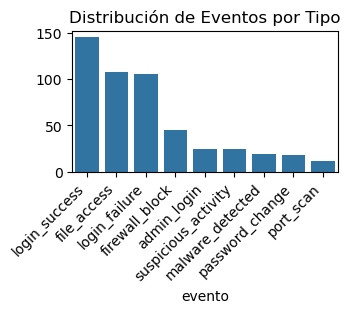

In [12]:
# 1. Distribución de eventos por tipo
plt.subplot(2, 2, 1)
eventos_count = logs_df['evento'].value_counts()
sns.barplot(x=eventos_count.index, y=eventos_count.values)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Eventos por Tipo')
plt.tight_layout()

Text(0.5, 1.0, 'Distribución de Eventos por Severidad')

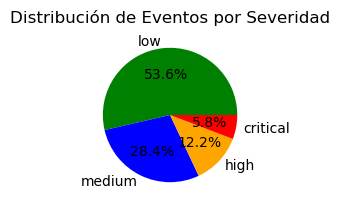

In [13]:
# 2. Distribución de eventos por severidad
plt.subplot(2, 2, 2)
severidad_count = logs_df['severidad'].value_counts()
colors = {'low': 'green', 'medium': 'blue', 'high': 'orange', 'critical': 'red'}
plt.pie(severidad_count, labels=severidad_count.index, autopct='%1.1f%%',
        colors=[colors[sev] for sev in severidad_count.index])
plt.title('Distribución de Eventos por Severidad')

Text(0, 0.5, 'Número de Eventos')

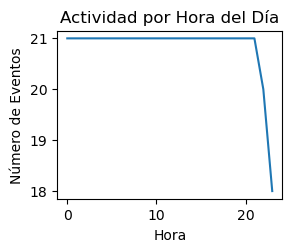

In [14]:
# 3. Actividad por hora del día
plt.subplot(2, 2, 3)
logs_df['hour'] = logs_df['timestamp'].dt.hour
hourly_count = logs_df.groupby('hour').size()
sns.lineplot(x=hourly_count.index, y=hourly_count.values)
plt.title('Actividad por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de Eventos')

<Figure size 1200x600 with 0 Axes>

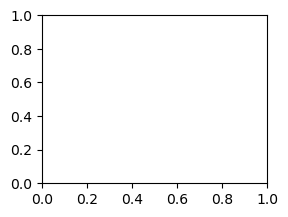

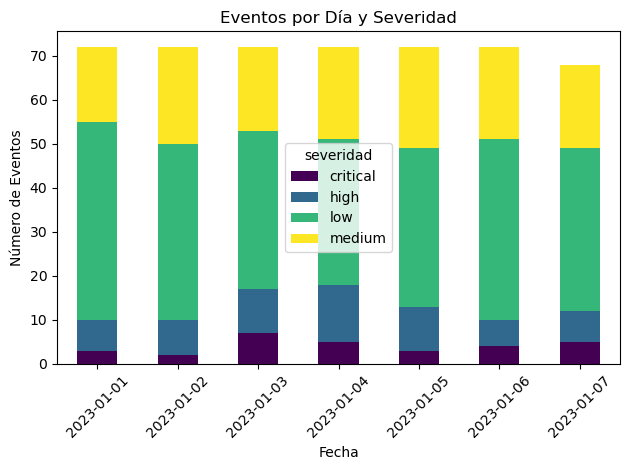

<Figure size 1200x600 with 0 Axes>

In [15]:
# 4. Eventos por día y por severidad
plt.subplot(2, 2, 4)
logs_df['date'] = logs_df['timestamp'].dt.date
pivot_table = pd.crosstab(logs_df['date'], logs_df['severidad'])
pivot_table.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Eventos por Día y Severidad')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('security_dashboard.png')
# Crear gráfico de actividad sospechosa
plt.figure(figsize=(12, 6))

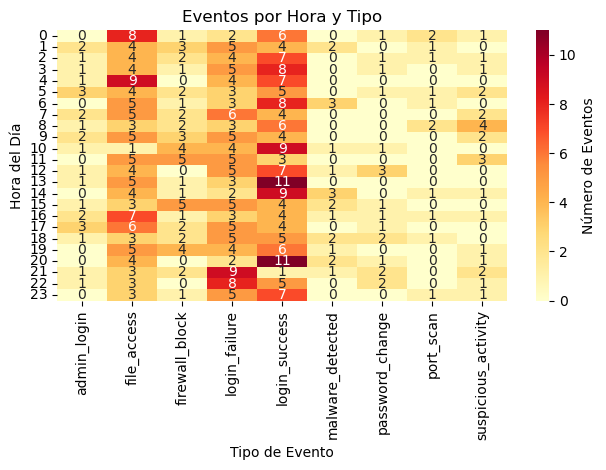

In [16]:
# 5. Mapa de calor de actividad por hora y tipo de evento
logs_df['hour'] = logs_df['timestamp'].dt.hour
heatmap_data = pd.crosstab(logs_df['hour'], logs_df['evento'])
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Número de Eventos'})
plt.title('Eventos por Hora y Tipo')
plt.xlabel('Tipo de Evento')
plt.ylabel('Hora del Día')
plt.tight_layout()
plt.savefig('activity_heatmap.png')

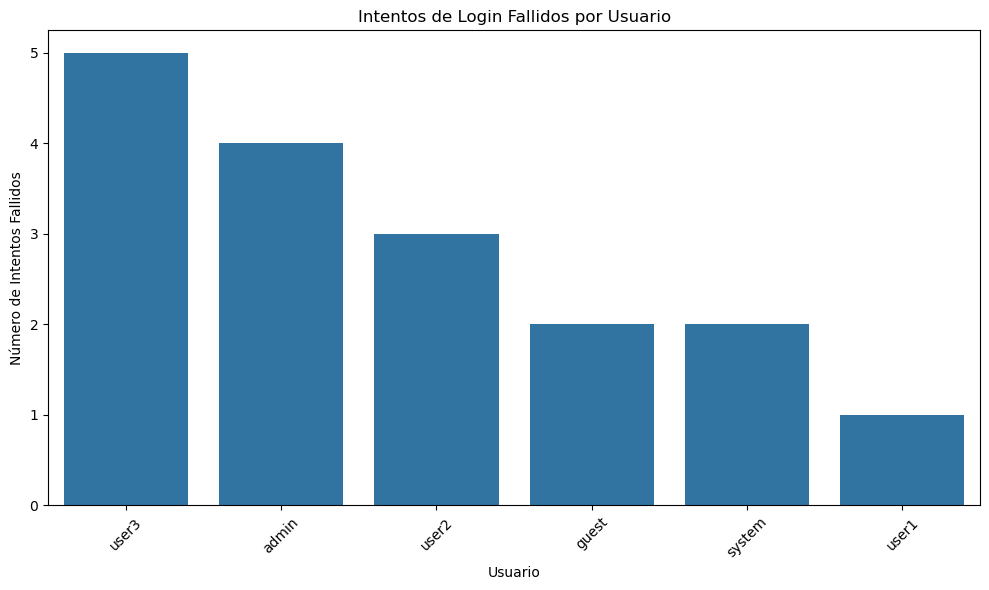

In [17]:
# 6. Análisis de accesos fallidos por usuario
plt.figure(figsize=(10, 6))
failed_logins = logs_df[(logs_df['evento'] == 'login_failure') & (logs_df['exitoso'] == False)]
user_failures = failed_logins['usuario'].value_counts()
sns.barplot(x=user_failures.index.fillna('anónimo'), y=user_failures.values)
plt.title('Intentos de Login Fallidos por Usuario')
plt.xlabel('Usuario')
plt.ylabel('Número de Intentos Fallidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('failed_logins_by_user.png')

Visualizaciones generadas correctamente. Revisa los archivos .png generados.


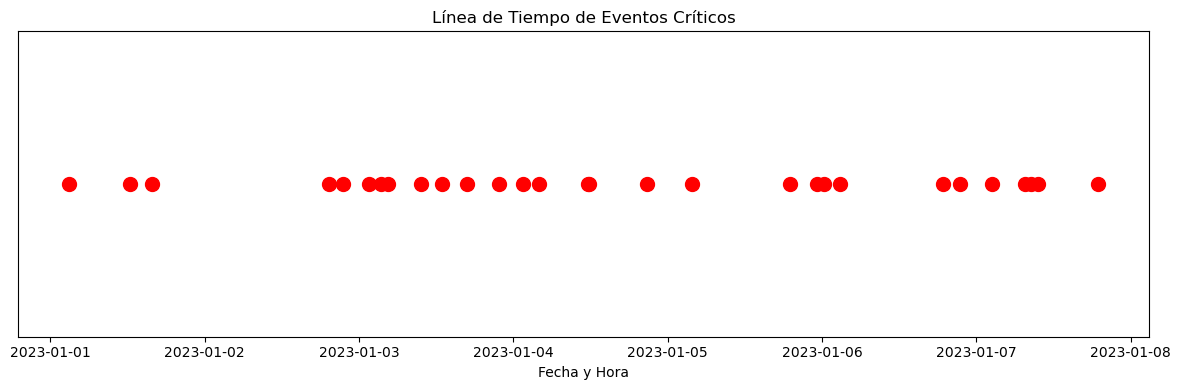

In [18]:
# 7. Línea de tiempo de eventos críticos
plt.figure(figsize=(12, 4))
critical_events = logs_df[logs_df['severidad'] == 'critical']
plt.scatter(critical_events['timestamp'], [1]*len(critical_events), c='red', s=100)
plt.yticks([])
plt.title('Línea de Tiempo de Eventos Críticos')
plt.xlabel('Fecha y Hora')
plt.tight_layout()
plt.savefig('critical_events_timeline.png')

print("Visualizaciones generadas correctamente. Revisa los archivos .png generados.")

# Comentario de Ejecución
## Codigo 1
Se procede a ejecutar el codigo sin novedad
## Codigo 2
Se procede a ejecutar el codigo sin novedad


# Ejemplo Propuesto
## Ejemplo 1: Apartir del codigo 2 - Descripción...

----------------------------------------------------------------------
Análisis y Visualización de Logs de Seguridad Simulados - GRUPO 7
----------------------------------------------------------------------
Este script genera datos de logs de seguridad simulados y crea
visualizaciones para analizar la distribución de eventos, severidad,
actividad por hora, actividad sospechosa, intentos de login fallidos,
y la línea de tiempo de eventos críticos.
----------------------------------------------------------------------



Visualizaciones generadas correctamente. Revisa los archivos .png generados.


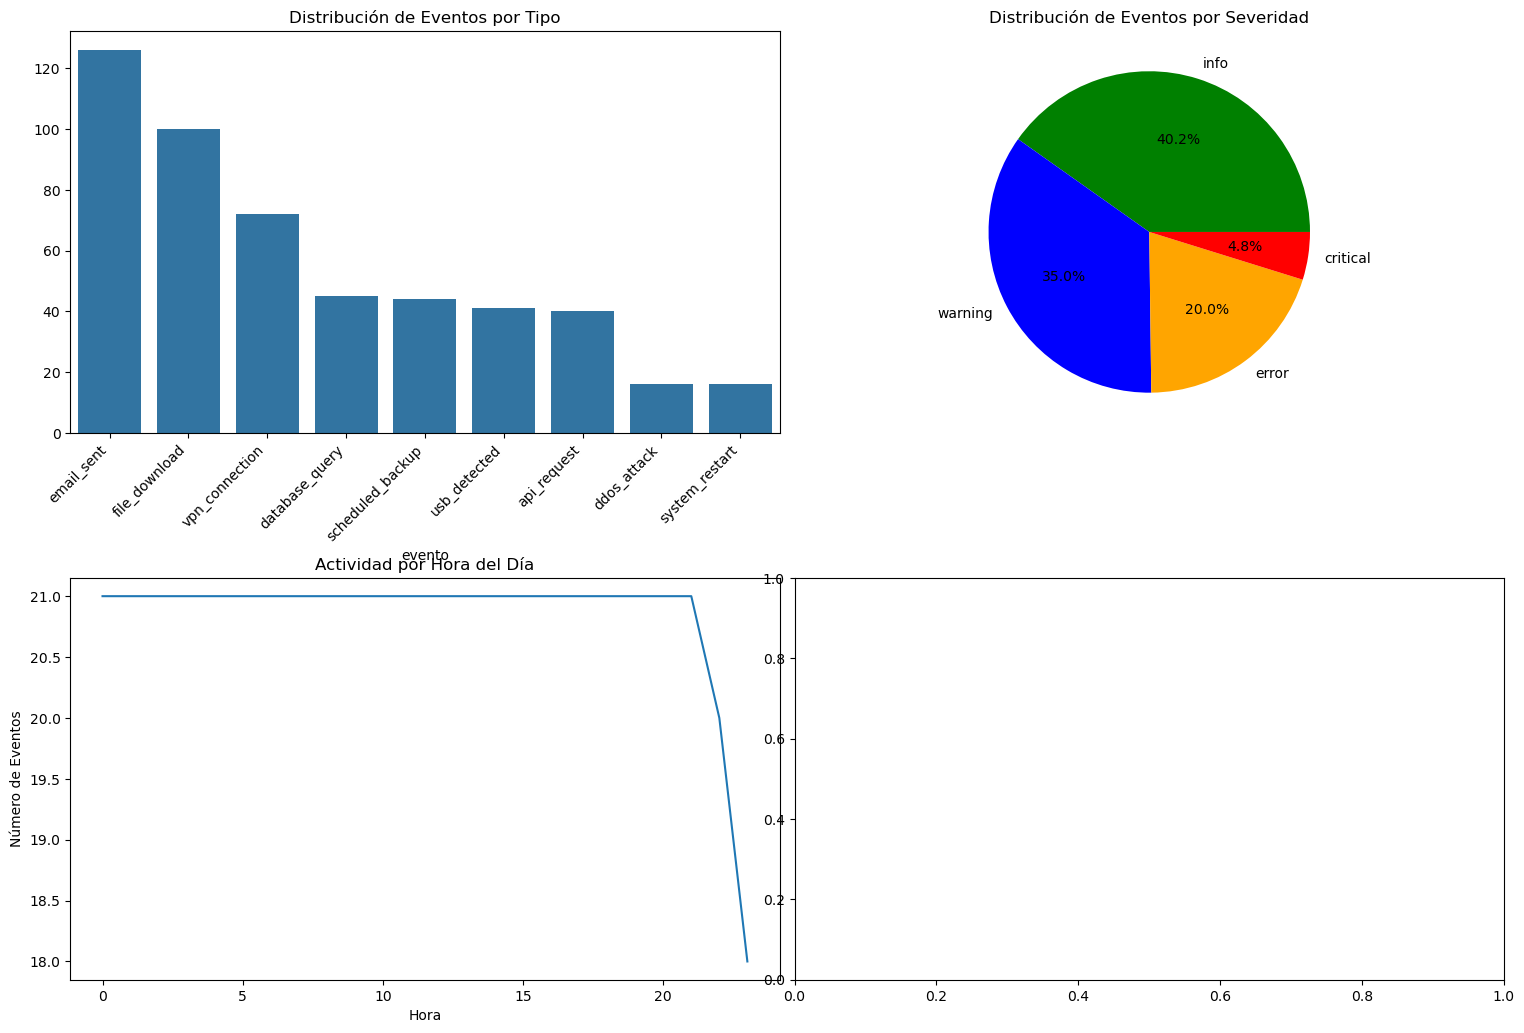

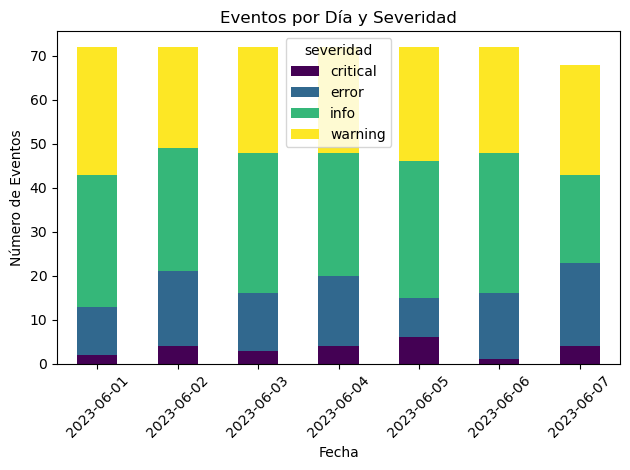

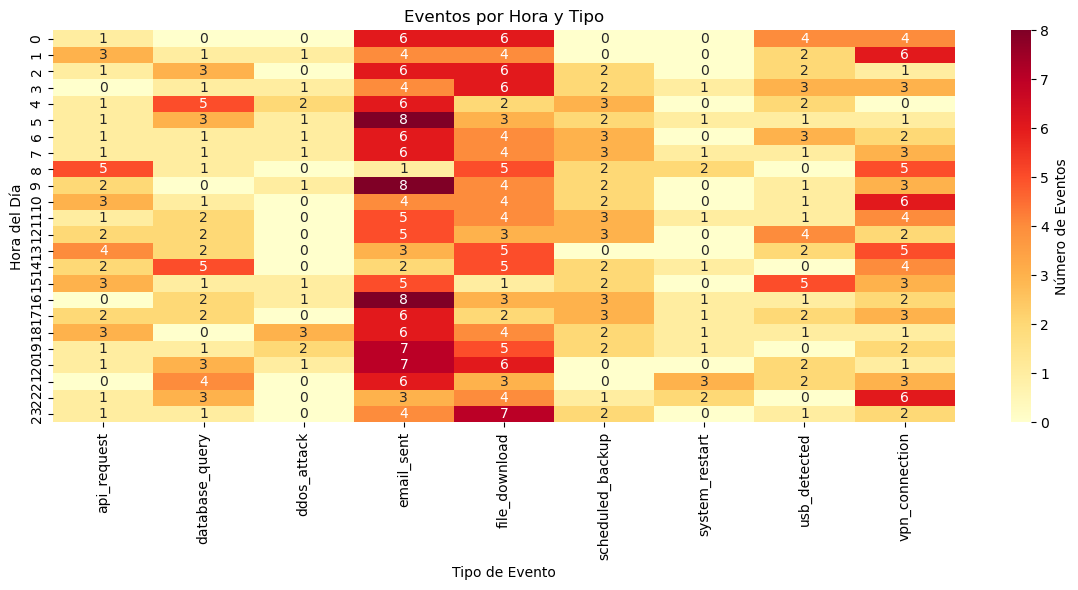

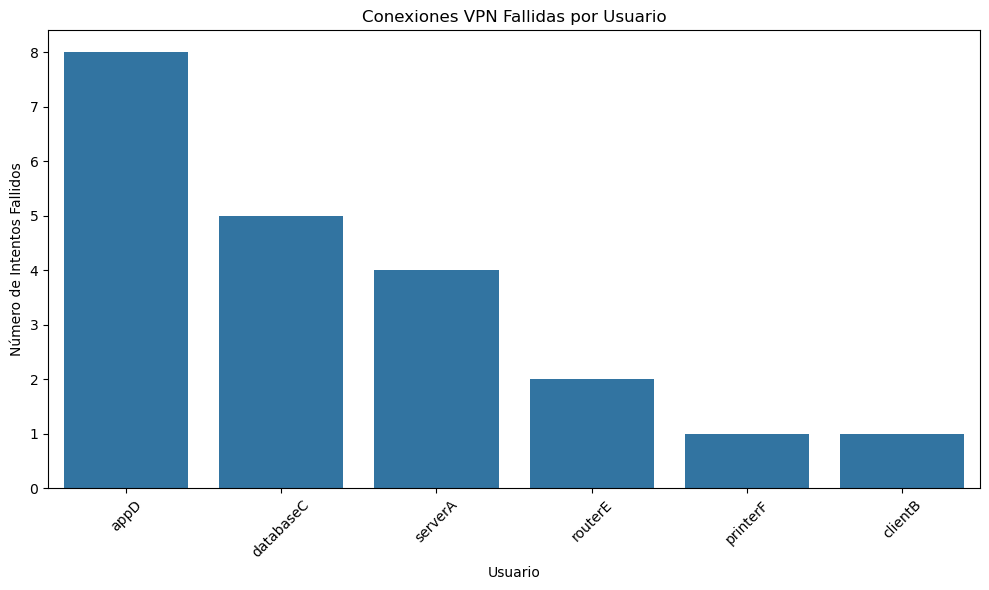

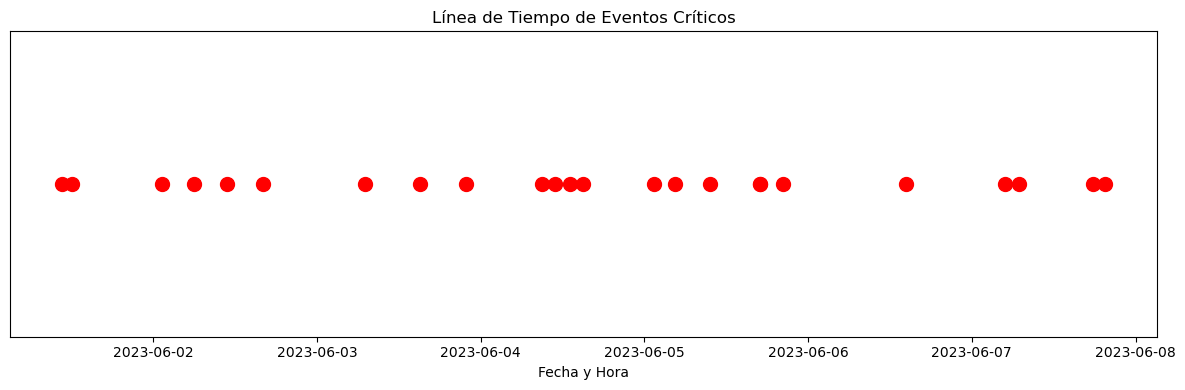

In [ ]:
print("----------------------------------------------------------------------")
print("Análisis y Visualización de Logs de Seguridad Simulados - GRUPO 7")
print("----------------------------------------------------------------------")
print("Este script genera datos de logs de seguridad simulados y")
print("visualizaciones para analizar la distribución de eventos, severidad,")
print("actividad por hora, actividad sospechosa, intentos de login fallidos,")
print("y la línea de tiempo de eventos críticos.")
print("----------------------------------------------------------------------\n")
# Generar 500 registros de logs simulados con datos diferentes
np.random.seed(123)  # Cambiamos a 123 para obtener datos diferentes

# Lista de eventos de seguridad diferentes
eventos = ['email_sent', 'file_download', 'vpn_connection', 'database_query',
            'api_request', 'usb_detected', 'scheduled_backup',
            'ddos_attack', 'system_restart']

# Generar timestamps para una semana diferente
fechas = pd.date_range(start='2023-06-01', periods=7)
timestamps = []
for fecha in fechas:
    for hora in range(24):
        for _ in range(3):  # 3 eventos por hora aprox
            timestamps.append(fecha + pd.Timedelta(hours=hora) +
                              pd.Timedelta(minutes=np.random.randint(60)))

# Ajustar al número de registros deseados
timestamps = timestamps[:500]

# Generar IPs aleatorias diferentes
def random_ip():
    return f"{np.random.randint(10, 200)}.{np.random.randint(10, 200)}.{np.random.randint(10, 200)}.{np.random.randint(10, 200)}"

# Usuarios del sistema diferentes
usuarios = ['serverA', 'clientB', 'databaseC', 'appD', 'routerE', 'printerF', None]

# Generar datos simulados diferentes
data = {
    'timestamp': timestamps,
    'ip_origen': [random_ip() for _ in range(500)],
    'evento': np.random.choice(eventos, 500, p=[0.25, 0.2, 0.15, 0.1, 0.1, 0.08, 0.07, 0.03, 0.02]),
    'usuario': np.random.choice(usuarios, 500, p=[0.15, 0.18, 0.17, 0.16, 0.12, 0.11, 0.11]),
    'severidad': np.random.choice(['info', 'warning', 'error', 'critical'], 500, p=[0.4, 0.35, 0.2, 0.05]),
    'exitoso': np.random.choice([True, False], 500, p=[0.7, 0.3]),
}

# Crear DataFrame
logs_df = pd.DataFrame(data)

# Configurar timestamp como índice
logs_df['timestamp'] = pd.to_datetime(logs_df['timestamp'])
logs_df = logs_df.sort_values('timestamp')

# Ahora creamos las visualizaciones (igual que antes)
plt.figure(figsize=(15, 10))

# 1. Distribución de eventos por tipo
plt.subplot(2, 2, 1)
eventos_count = logs_df['evento'].value_counts()
sns.barplot(x=eventos_count.index, y=eventos_count.values)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Eventos por Tipo')
plt.tight_layout()

# 2. Distribución de eventos por severidad
plt.subplot(2, 2, 2)
severidad_count = logs_df['severidad'].value_counts()
colors = {'info': 'green', 'warning': 'blue', 'error': 'orange', 'critical': 'red'}
plt.pie(severidad_count, labels=severidad_count.index, autopct='%1.1f%%',
        colors=[colors[sev] for sev in severidad_count.index])
plt.title('Distribución de Eventos por Severidad')

# 3. Actividad por hora del día
plt.subplot(2, 2, 3)
logs_df['hour'] = logs_df['timestamp'].dt.hour
hourly_count = logs_df.groupby('hour').size()
sns.lineplot(x=hourly_count.index, y=hourly_count.values)
plt.title('Actividad por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de Eventos')

# 4. Eventos por día y por severidad
plt.subplot(2, 2, 4)
logs_df['date'] = logs_df['timestamp'].dt.date
pivot_table = pd.crosstab(logs_df['date'], logs_df['severidad'])
pivot_table.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Eventos por Día y Severidad')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Grupo7-security_dashboard_2.png')

# Crear gráfico de actividad sospechosa
plt.figure(figsize=(12, 6))

# 5. Mapa de calor de actividad por hora y tipo de evento
logs_df['hour'] = logs_df['timestamp'].dt.hour
heatmap_data = pd.crosstab(logs_df['hour'], logs_df['evento'])
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Número de Eventos'})
plt.title('Eventos por Hora y Tipo')
plt.xlabel('Tipo de Evento')
plt.ylabel('Hora del Día')
plt.tight_layout()
plt.savefig('Grupo7-activity_heatmap_2.png')

# 6. Análisis de accesos fallidos por usuario
plt.figure(figsize=(10, 6))
failed_logins = logs_df[(logs_df['evento'] == 'vpn_connection') & (logs_df['exitoso'] == False)]
user_failures = failed_logins['usuario'].value_counts()
sns.barplot(x=user_failures.index.fillna('anónimo'), y=user_failures.values)
plt.title('Conexiones VPN Fallidas por Usuario')
plt.xlabel('Usuario')
plt.ylabel('Número de Intentos Fallidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Grupo7-failed_logins_by_user_2.png')

# 7. Línea de tiempo de eventos críticos
plt.figure(figsize=(12, 4))
critical_events = logs_df[logs_df['severidad'] == 'critical']
plt.scatter(critical_events['timestamp'], [1]*len(critical_events), c='red', s=100)
plt.yticks([])
plt.title('Línea de Tiempo de Eventos Críticos')
plt.xlabel('Fecha y Hora')
plt.tight_layout()
plt.savefig('Grupo7-critical_events_timeline_2.png')

print("Visualizaciones generadas correctamente. Revisa los archivos .png generados.")

## Ejemplo 2: Apartir del código 1 - Se propone generar un registro de logs de modificaciones de politicas por usuarios.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("----------------------------------------------------------------------")
print("Análisis y Visualización de modificaciones de politicas - GRUPO 7")
print("----------------------------------------------------------------------")
print("Este script genera datos de logs de seguridad simulados de modificacion")
print("de politicas por distintos usuarios, ciertos usuarios estan permitidos y otros no.")

# Creamos un dataset simulando un registro de modificaciones de políticas
data = {
    'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='h'),  # Usamos 'h' en minúscula
    'ip_origen': ['192.168.1.' + str(i) for i in range(1, 11)],  # Direcciones IP de origen
    'usuario': ['chidalgo1', 'aperez1', 'mgarcia1', 'jdoe1', 'asmith1', 'chidalgo1', 'aperez1', 'mgarcia1', 'jdoe1', 'asmith1'],  # Usuarios
    'accion': ['crear', 'modificar', 'eliminar', 'modificar', 'crear', 'eliminar', 'modificar', 'crear', 'eliminar', 'modificar'],  # Acciones realizadas
    'politica_afectada': ['POL001', 'POL002', 'POL001', 'POL003', 'POL002', 'POL003', 'POL001', 'POL002', 'POL003', 'POL001'],  # Políticas afectadas
    'bytes_modificados': np.random.randint(100, 10000, 10),  # Simula el tamaño de los cambios
    'exito_accion': [True, True, False, True, True, True, False, False, True, True]  # Éxito de la acción
}

# Creamos el DataFrame
df = pd.DataFrame(data)

print("\n1. Explorando el DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

# 2. Selección de datos
print("\n2. Selección de datos:")
# Seleccionar una columna (devuelve una Serie)
print("\nSelección de una columna (Serie):")
print(df['usuario'])

# Seleccionar múltiples columnas (devuelve un DataFrame)
print("\nSelección de múltiples columnas (DataFrame):")
print(df[['ip_origen', 'usuario', 'accion']])

# Selección por índice con iloc
print("\nSelección por índice con iloc (primeras 2 filas, columnas 0 y 2):")
print(df.iloc[0:2, [0, 2]])

# Selección por nombre con loc
print("\nSelección por nombre con loc (filas donde la acción es 'modificar'):")
print(df.loc[df['accion'] == 'modificar', ['timestamp', 'ip_origen', 'usuario', 'politica_afectada']])

# 3. Filtrado de datos
print("\n3. Filtrado de datos:")
# Filtrar acciones exitosas
acciones_exitosas = df[df['exito_accion'] == True]
print("\nAcciones exitosas:")
print(acciones_exitosas[['timestamp', 'ip_origen', 'usuario', 'accion']])

# Filtrado múltiple (acciones de modificación en la política POL001 por usuarios permitidos)
usuarios_permitidos = ['chidalgo1', 'aperez1', 'mgarcia1']
modificaciones_pol001 = df[(df['accion'] == 'modificar') & 
                           (df['politica_afectada'] == 'POL001') & 
                           (df['usuario'].isin(usuarios_permitidos))]
print("\nModificaciones en POL001 por usuarios permitidos:")
print(modificaciones_pol001)

# 4. Transformación de datos
print("\n4. Transformación de datos:")
# Añadir una nueva columna con la hora del día
df['hora'] = df['timestamp'].dt.hour
print("\nDataFrame con nueva columna 'hora':")
print(df[['timestamp', 'hora', 'ip_origen', 'usuario', 'accion']])

# Aplicar una función con apply para clasificar acciones
def clasificar_accion(accion):
    if accion == 'crear':
        return 'ALTA'
    elif accion == 'modificar':
        return 'MEDIO'
    elif accion == 'eliminar':
        return 'CRITICO'
    else:
        return 'OTRO'

df['tipo_accion'] = df['accion'].apply(clasificar_accion)
print("\nDataFrame con clasificación de acciones:")
print(df[['accion', 'tipo_accion']])

# 5. Agregación de datos
print("\n5. Agregación de datos:")
# Agrupar por usuario y contar acciones
conteo_por_usuario = df.groupby('usuario').size()
print("\nConteo de acciones por usuario:")
print(conteo_por_usuario)

# Estadísticas por política afectada
stats_por_politica = df.groupby('politica_afectada')['bytes_modificados'].agg(['count', 'mean', 'min', 'max'])
print("\nEstadísticas de bytes modificados por política:")
print(stats_por_politica)

# 6. Pivotado de datos
print("\n6. Pivotado de datos:")
# Tabla pivote de bytes modificados por tipo de acción y éxito de la acción
pivot = pd.pivot_table(df, 
                       values='bytes_modificados', 
                       index='tipo_accion', 
                       columns='exito_accion', 
                       aggfunc='mean')
print("\nTabla pivote de bytes modificados por tipo de acción y éxito de la acción:")
print(pivot)

# 7. Detección de anomalías simples
print("\n7. Detección de anomalías simples:")
# Calcular el Z-score para identificar valores atípicos en bytes_modificados
df['z_score'] = (df['bytes_modificados'] - df['bytes_modificados'].mean()) / df['bytes_modificados'].std()
anomalias = df[abs(df['z_score']) > 1.5]  # Consideramos como anómalos Z-scores > 1.5
print("\nPosibles acciones anómalas por volumen de datos modificados:")
print(anomalias[['timestamp', 'ip_origen', 'usuario', 'accion', 'bytes_modificados', 'z_score']])

----------------------------------------------------------------------
Análisis y Visualización de modificaciones de politicas - GRUPO 7
----------------------------------------------------------------------
Este script genera datos de logs de seguridad simulados de modificacion
de politicas por distintos usuarios, ciertos usuarios estan permitidos y otros no.

1. Explorando el DataFrame:
            timestamp    ip_origen    usuario     accion politica_afectada  \
0 2023-01-01 00:00:00  192.168.1.1  chidalgo1      crear            POL001   
1 2023-01-01 01:00:00  192.168.1.2    aperez1  modificar            POL002   
2 2023-01-01 02:00:00  192.168.1.3   mgarcia1   eliminar            POL001   
3 2023-01-01 03:00:00  192.168.1.4      jdoe1  modificar            POL003   
4 2023-01-01 04:00:00  192.168.1.5    asmith1      crear            POL002   

   bytes_modificados  exito_accion  
0               5364          True  
1               6672          True  
2               4525        